In [2]:
import s3fs
import pandas as pd
fs = s3fs.S3FileSystem(
    endpoint_url="https://minio.lab.sspcloud.fr",
    client_kwargs={"region_name": "us-east-1"},
)

## Examples

In [39]:
NAIVE_PATH = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/2026-03-16_google-gemma-3-27b-it_temp14_fewshot6_exhaustive.parquet"
RETEXT_PATH = "s3://projet-ape/synthetic_data_test/naive/NAF2025_FR/retext-2026-06-05_gemma4-26b-moe_temp10_fewshot6_exhaustive.parquet"

df_naive = pd.read_parquet(NAIVE_PATH, filesystem=fs)
df_retext = pd.read_parquet(RETEXT_PATH, filesystem=fs)

In [53]:
sample = df_naive.sample(
n=10,
random_state=42
).reset_index(
    drop=True
).rename(
    columns={"label": "Naive Code2Text", "name": "Title"}
).merge(
    df_retext[["code", "label"]],
    on="code",
    how="left"
).rename(
    columns={"label": "Code2ReText", "code": "Code"}
).groupby(
    "Code"
).agg("first")

In [55]:
sample.to_csv("gen_examples.csv", sep=";", quoting=1)

## Wasserstein distance train

In [64]:
DATASET_METRICS_PATH = "s3://mateom/graal/compare_datasets.parquet"
COLLECTION_A = "naive_synth"
COLLECTION_B = "retext_exhaustive"
COLLECTION_C = "original_cleaned"

df_metrics = pd.read_parquet(DATASET_METRICS_PATH, filesystem=fs)
df_metrics = df_metrics[df_metrics["count_C"] >= 50]
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 55.90Y to 96.10H
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   count_A                  373 non-null    int64  
 1   count_B                  373 non-null    int64  
 2   count_C                  373 non-null    int64  
 3   wasserstein_distance_AC  373 non-null    float64
 4   wasserstein_distance_BC  373 non-null    float64
 5   wasserstein_distance_AB  373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 20.4+ KB


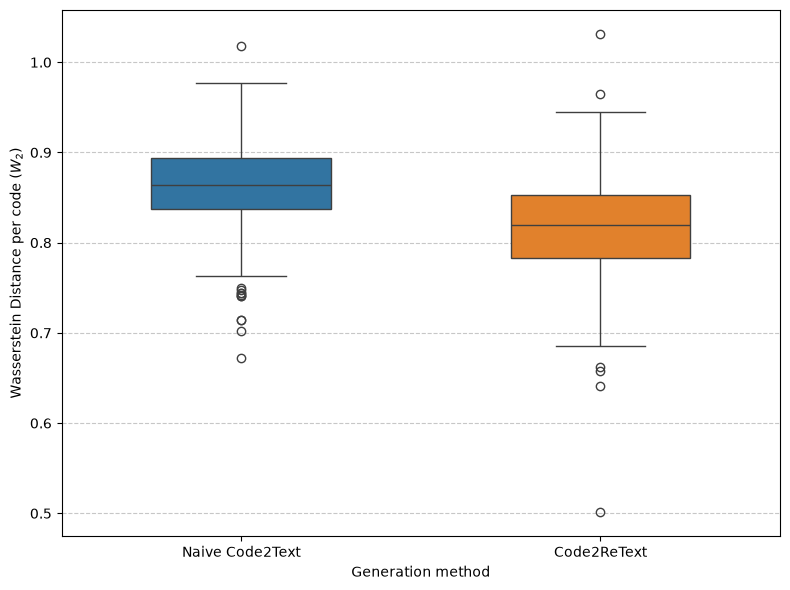

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_plot = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].rename(
    columns={
        "wasserstein_distance_AC": "Naive Code2Text",
        "wasserstein_distance_BC": "Code2ReText",
    }
)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

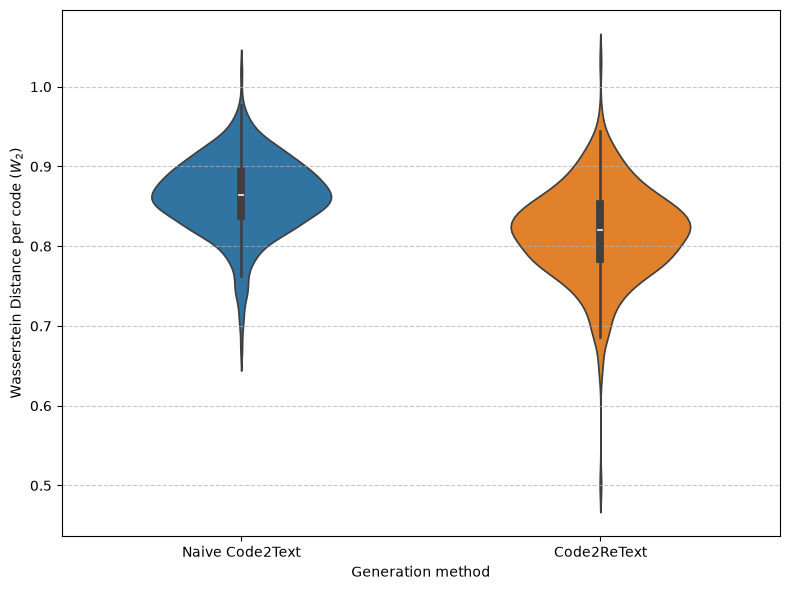

In [66]:
plt.figure(figsize=(8, 6))

sns.violinplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [67]:
# Extraction des séries en enlevant les potentielles valeurs manquantes (NaN)
# dues aux codes absents de certaines collections
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du test de Wilcoxon pour données appariées
stat, p_value = stats.wilcoxon(group_A, group_B)

print("--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---")
print(f"Statistique de test : {stat:.2f}")
print(f"p-value : {p_value:.5e}")

# Interprétation bayésienne/fréquentiste standard (seuil alpha à 5%)
alpha = 0.05
if p_value < alpha:
    print("\nConclusion : La différence est statistiquement significative (p < 0.05).")
    median_A = group_A.median()
    median_B = group_B.median()
    if median_B < median_A:
        print(f"Code2ReText (Médiane: {median_B:.4f}) est significativement plus proche de l'original C que Naive Code2Text (Médiane: {median_A:.4f}).")
    else:
        print(f"Naive Code2Text (Médiane: {median_A:.4f}) est significativement plus proche.")
else:
    print("\nConclusion : Pas de différence statistiquement significative détectée (p >= 0.05). Les deux méthodes ont des distributions de distances similaires.")

--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---
Statistique de test : 3653.00
p-value : 9.36633e-51

Conclusion : La différence est statistiquement significative (p < 0.05).
Code2ReText (Médiane: 0.8198) est significativement plus proche de l'original C que Naive Code2Text (Médiane: 0.8645).


In [68]:
from scipy import stats

# Nettoyage des données pour aligner parfaitement les codes
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du t-test apparié
t_stat, p_value = stats.ttest_rel(group_A, group_B)

print("--- Résultats du T-Test Apparié (Paired T-Test) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value : {p_value:.5e}")

alpha = 0.05
if p_value < alpha:
    mean_A = group_A.mean()
    mean_B = group_B.mean()
    print(f"\nConclusion : Différence statistiquement significative (p < 0.05).")
    if mean_B < mean_A:
        print(f"Code2ReText (Moyenne: {mean_B:.4f}) surpasse Naive Code2Text (Moyenne: {mean_A:.4f}) en se rapprochant de l'original.")
    else:
        print(f"Naive Code2Text (Moyenne: {mean_A:.4f}) est statistiquement plus proche.")
else:
    print("\nConclusion : Aucune différence statistiquement significative constatée.")

--- Résultats du T-Test Apparié (Paired T-Test) ---
Statistique t : 20.1415
p-value : 1.54425e-61

Conclusion : Différence statistiquement significative (p < 0.05).
Code2ReText (Moyenne: 0.8170) surpasse Naive Code2Text (Moyenne: 0.8629) en se rapprochant de l'original.


In [69]:
import pingouin as pg

# Nettoyage et alignement des données
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

# Calcul du t-test bayésien apparié
# 'paired=True' active la comparaison intra-code
res = pg.ttest(
    df_clean["wasserstein_distance_AC"], 
    df_clean["wasserstein_distance_BC"], 
    paired=True
)

# Extraction des indicateurs clés
bf10 = res['BF10'].astype(float).values[0]
d_cohen = res['cohen_d'].values[0]
p_val = res['p_val'].values[0]  # Fourni aussi par pingouin pour comparaison

print("--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---")
print(f"Facteur de Bayes (BF10) : {bf10:.4e}")
print(f"Taille de l'effet (d de Cohen) : {d_cohen:.4f}")

print("\n--- INTERPRÉTATION BAYÉSIENNE ---")
# Échelle d'interprétation de Jeffreys pour le Facteur de Bayes
if bf10 > 100:
    print("Preuve extrême en faveur d'une différence entre les deux méthodes.")
elif bf10 > 30:
    print("Preuve très forte en faveur d'une différence.")
elif bf10 > 10:
    print("Preuve forte en faveur d'une différence.")
elif bf10 > 3:
    print("Preuve modérée en faveur d'une différence.")
elif 1/3 <= bf10 <= 3:
    print("Les données sont anecdotiques, impossible de trancher (les deux modèles se valent).")
elif bf10 < 1/10:
    print("Preuve forte en faveur de l'hypothèse nulle (les méthodes sont strictement équivalentes).")
else:
    print("Preuve modérée/extrême en faveur de l'hypothèse nulle.")

# Analyse directionnelle
mean_AC = df_clean["wasserstein_distance_AC"].mean()
mean_BC = df_clean["wasserstein_distance_BC"].mean()
print(f"\nDistance moyenne AC (Naïve) : {mean_AC:.4f}")
print(f"Distance moyenne BC (ReText) : {mean_BC:.4f}")

if bf10 > 3:
    if mean_BC < mean_AC:
        print("Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.")
    else:
        print("Conclusion : La méthode Naïve reste plus proche de l'original.")

--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---
Facteur de Bayes (BF10) : 9.8720e+57
Taille de l'effet (d de Cohen) : 0.8825

--- INTERPRÉTATION BAYÉSIENNE ---
Preuve extrême en faveur d'une différence entre les deux méthodes.

Distance moyenne AC (Naïve) : 0.8629
Distance moyenne BC (ReText) : 0.8170
Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.


## Wasserstein distance test

In [71]:
DATASET_METRICS_PATH = "s3://mateom/graal/compare_datasets_test.parquet"
COLLECTION_A = "naive_synth"
COLLECTION_B = "retext_exhaustive"
COLLECTION_C = "test_prod"

df_metrics = pd.read_parquet(DATASET_METRICS_PATH, filesystem=fs)

df_metrics = df_metrics[df_metrics["count_C"] >= 50]
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 55.90Y to 96.21G
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   count_A                  270 non-null    int64  
 1   count_B                  270 non-null    int64  
 2   count_C                  270 non-null    int64  
 3   wasserstein_distance_AC  270 non-null    float64
 4   wasserstein_distance_BC  270 non-null    float64
 5   wasserstein_distance_AB  270 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 14.8+ KB


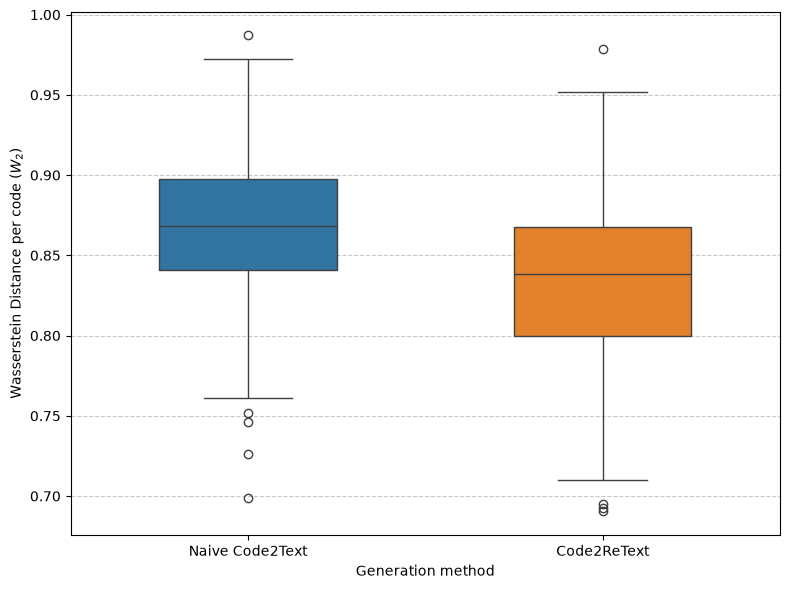

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_plot = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].rename(
    columns={
        "wasserstein_distance_AC": "Naive Code2Text",
        "wasserstein_distance_BC": "Code2ReText",
    }
)

plt.figure(figsize=(8, 6))

sns.boxplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

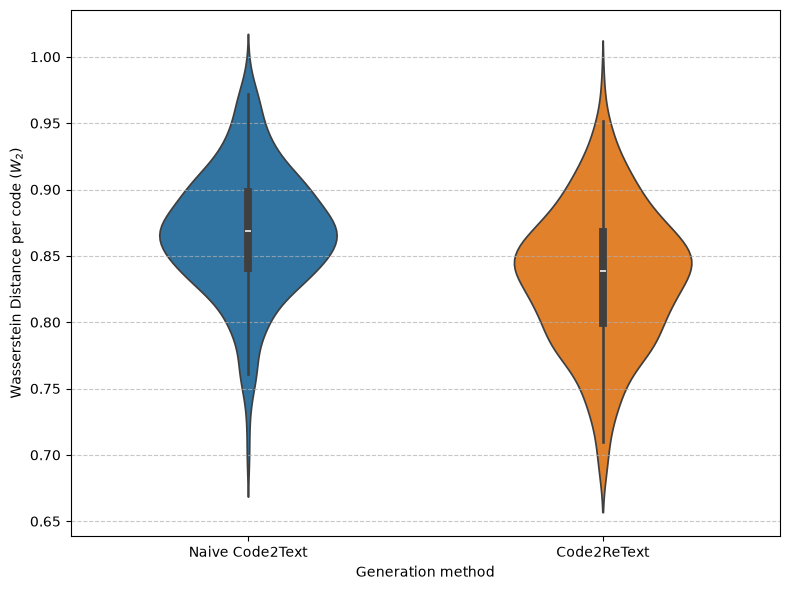

In [73]:
plt.figure(figsize=(8, 6))

sns.violinplot(data=df_plot, width=0.5)

plt.ylabel("Wasserstein Distance per code ($W_2$)", fontsize=10)
plt.xlabel("Generation method", fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [74]:
# Extraction des séries en enlevant les potentielles valeurs manquantes (NaN)
# dues aux codes absents de certaines collections
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du test de Wilcoxon pour données appariées
stat, p_value = stats.wilcoxon(group_A, group_B)

print("--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---")
print(f"Statistique de test : {stat:.2f}")
print(f"p-value : {p_value:.5e}")

# Interprétation bayésienne/fréquentiste standard (seuil alpha à 5%)
alpha = 0.05
if p_value < alpha:
    print("\nConclusion : La différence est statistiquement significative (p < 0.05).")
    median_A = group_A.median()
    median_B = group_B.median()
    if median_B < median_A:
        print(f"Code2ReText (Médiane: {median_B:.4f}) est significativement plus proche de l'original C que Naive Code2Text (Médiane: {median_A:.4f}).")
    else:
        print(f"Naive Code2Text (Médiane: {median_A:.4f}) est significativement plus proche.")
else:
    print("\nConclusion : Pas de différence statistiquement significative détectée (p >= 0.05). Les deux méthodes ont des distributions de distances similaires.")

--- Résultats du Test Statistique (Wilcoxon Signed-Rank) ---
Statistique de test : 3093.00
p-value : 2.57218e-32

Conclusion : La différence est statistiquement significative (p < 0.05).
Code2ReText (Médiane: 0.8384) est significativement plus proche de l'original C que Naive Code2Text (Médiane: 0.8684).


In [75]:
from scipy import stats

# Nettoyage des données pour aligner parfaitement les codes
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

group_A = df_clean["wasserstein_distance_AC"]
group_B = df_clean["wasserstein_distance_BC"]

# Exécution du t-test apparié
t_stat, p_value = stats.ttest_rel(group_A, group_B)

print("--- Résultats du T-Test Apparié (Paired T-Test) ---")
print(f"Statistique t : {t_stat:.4f}")
print(f"p-value : {p_value:.5e}")

alpha = 0.05
if p_value < alpha:
    mean_A = group_A.mean()
    mean_B = group_B.mean()
    print(f"\nConclusion : Différence statistiquement significative (p < 0.05).")
    if mean_B < mean_A:
        print(f"Code2ReText (Moyenne: {mean_B:.4f}) surpasse Naive Code2Text (Moyenne: {mean_A:.4f}) en se rapprochant de l'original.")
    else:
        print(f"Naive Code2Text (Moyenne: {mean_A:.4f}) est statistiquement plus proche.")
else:
    print("\nConclusion : Aucune différence statistiquement significative constatée.")

--- Résultats du T-Test Apparié (Paired T-Test) ---
Statistique t : 14.6033
p-value : 5.79008e-36

Conclusion : Différence statistiquement significative (p < 0.05).
Code2ReText (Moyenne: 0.8338) surpasse Naive Code2Text (Moyenne: 0.8673) en se rapprochant de l'original.


In [76]:
import pingouin as pg

# Nettoyage et alignement des données
df_clean = df_metrics[["wasserstein_distance_AC", "wasserstein_distance_BC"]].dropna()

# Calcul du t-test bayésien apparié
# 'paired=True' active la comparaison intra-code
res = pg.ttest(
    df_clean["wasserstein_distance_AC"], 
    df_clean["wasserstein_distance_BC"], 
    paired=True
)

# Extraction des indicateurs clés
bf10 = res['BF10'].astype(float).values[0]
d_cohen = res['cohen_d'].values[0]
p_val = res['p_val'].values[0]  # Fourni aussi par pingouin pour comparaison

print("--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---")
print(f"Facteur de Bayes (BF10) : {bf10:.4e}")
print(f"Taille de l'effet (d de Cohen) : {d_cohen:.4f}")

print("\n--- INTERPRÉTATION BAYÉSIENNE ---")
# Échelle d'interprétation de Jeffreys pour le Facteur de Bayes
if bf10 > 100:
    print("Preuve extrême en faveur d'une différence entre les deux méthodes.")
elif bf10 > 30:
    print("Preuve très forte en faveur d'une différence.")
elif bf10 > 10:
    print("Preuve forte en faveur d'une différence.")
elif bf10 > 3:
    print("Preuve modérée en faveur d'une différence.")
elif 1/3 <= bf10 <= 3:
    print("Les données sont anecdotiques, impossible de trancher (les deux modèles se valent).")
elif bf10 < 1/10:
    print("Preuve forte en faveur de l'hypothèse nulle (les méthodes sont strictement équivalentes).")
else:
    print("Preuve modérée/extrême en faveur de l'hypothèse nulle.")

# Analyse directionnelle
mean_AC = df_clean["wasserstein_distance_AC"].mean()
mean_BC = df_clean["wasserstein_distance_BC"].mean()
print(f"\nDistance moyenne AC (Naïve) : {mean_AC:.4f}")
print(f"Distance moyenne BC (ReText) : {mean_BC:.4f}")

if bf10 > 3:
    if mean_BC < mean_AC:
        print("Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.")
    else:
        print("Conclusion : La méthode Naïve reste plus proche de l'original.")

--- RÉSULTATS DU T-TEST BAYÉSIEN APPARIÉ ---
Facteur de Bayes (BF10) : 4.4990e+32
Taille de l'effet (d de Cohen) : 0.6842

--- INTERPRÉTATION BAYÉSIENNE ---
Preuve extrême en faveur d'une différence entre les deux méthodes.

Distance moyenne AC (Naïve) : 0.8673
Distance moyenne BC (ReText) : 0.8338
Conclusion : La méthode Code2ReText réduit significativement la distance sémantique avec l'original.
